# Notebook Overview

This notebook aims to perform word embeddings using 2 hidden layers in the embedding layer. To establish context

The future king is the prince
Daughter is the princess
Son is the prince
Only a man can be a king
Only a woman can be a queen
The princess will be a queen
The prince is a strong man
The princess is a beautiful woman
Prince is only a boy now
Prince will be king
A boy will be a man




# Loading Data

In [ ]:
from google.colab import files
uploaded = files.upload()
File = open('royal.txt','r')
royal_data = File.read()
print(royal_data)

Saving royal.txt to royal.txt
The future king is the prince
Daughter is the princess
Son is the prince
Only a man can be a king
Only a woman can be a queen
The princess will be a queen
The prince is a strong man
The princess is a beautiful woman
Prince is only a boy now
Prince will be king
A boy will be a man





In [ ]:
print(len(royal_data))

283


In [ ]:
royal_data = royal_data.split('\n')

In [ ]:
print(royal_data)

['The future king is the prince', 'Daughter is the princess', 'Son is the prince', 'Only a man can be a king', 'Only a woman can be a queen', 'The princess will be a queen', 'The prince is a strong man', 'The princess is a beautiful woman', 'Prince is only a boy now', 'Prince will be king', 'A boy will be a man', '', '', '']


In [ ]:
print(len(royal_data))

14


In [ ]:
for i in range(len(royal_data)):
  royal_data[i] = royal_data[i].lower()
print(royal_data)

['the future king is the prince', 'daughter is the princess', 'son is the prince', 'only a man can be a king', 'only a woman can be a queen', 'the princess will be a queen', 'the prince is a strong man', 'the princess is a beautiful woman', 'prince is only a boy now', 'prince will be king', 'a boy will be a man', '', '', '']


#Remove Stopwords
Words that dont any meaning to the sentence

In [ ]:
stopwords = ['the', 'is', 'will', 'be', 'a', 'only', 'can', 'their', 'now', 'and', 'at', 'it']

# Word Tokenization

In [ ]:
for sent in royal_data:
  for word in sent.split():
    print(word)

the
future
king
is
the
prince
daughter
is
the
princess
son
is
the
prince
only
a
man
can
be
a
king
only
a
woman
can
be
a
queen
the
princess
will
be
a
queen
the
prince
is
a
strong
man
the
princess
is
a
beautiful
woman
prince
is
only
a
boy
now
prince
will
be
king
a
boy
will
be
a
man


In [ ]:
filtered_words = []
for sent in royal_data:
  temp = []
  for word in sent.split():
    if word not in stopwords:
      temp.append(word)
  filtered_words.append(temp)
print(filtered_words)









[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king'], ['boy', 'man'], [], [], []]


In [ ]:
max_list_length = max(len(sublist) for sublist in filtered_words)
print(max_list_length)


3


In [ ]:
print(filtered_words[:10])

[['future', 'king', 'prince'], ['daughter', 'princess'], ['son', 'prince'], ['man', 'king'], ['woman', 'queen'], ['princess', 'queen'], ['prince', 'strong', 'man'], ['princess', 'beautiful', 'woman'], ['prince', 'boy'], ['prince', 'king']]


## Explaining Bigrams





In Natural Language Processing (NLP), a **bigram** is a sequence of two adjacent words or tokens found in a text. It is a simple form of an **n-gram**, where 'n' specifically equals 2. Bigrams are widely used in various NLP tasks such as text analysis, language modeling (predicting the next word in a sequence), and feature extraction for machine learning models.

**General Example:**

Consider the sentence: "I like natural language processing"

Breaking this sentence into bigrams would result in the following pairs:
- ("I", "like")
- ("like", "natural")
- ("natural", "language")
- ("language", "processing")

**Example using `filtered_words`:**

From our `filtered_words` list, let's take the first sublist:
`['future', 'king', 'prince']`

The bigrams that can be formed from this sequence are:
- ('future', 'king')
- ('king', 'prince')

Similarly, for `['daughter', 'princess']` the bigram would be:
- ('daughter', 'princess')

# Creating Bigrams

In [ ]:
bigrams = []
for word_list in filtered_words:#loops through each list
  for i in range(len(word_list)-1):#subtract by 1 to stop just before the last  word because it doesnt have a patner
    for j in range(i+1, len(word_list)):#loop starts at exactly the second word
      bigrams.append((word_list[i], word_list[j]))
      bigrams.append([word_list[j], word_list[i]])
print(bigrams)


[('future', 'king'), ['king', 'future'], ('future', 'prince'), ['prince', 'future'], ('king', 'prince'), ['prince', 'king'], ('daughter', 'princess'), ['princess', 'daughter'], ('son', 'prince'), ['prince', 'son'], ('man', 'king'), ['king', 'man'], ('woman', 'queen'), ['queen', 'woman'], ('princess', 'queen'), ['queen', 'princess'], ('prince', 'strong'), ['strong', 'prince'], ('prince', 'man'), ['man', 'prince'], ('strong', 'man'), ['man', 'strong'], ('princess', 'beautiful'), ['beautiful', 'princess'], ('princess', 'woman'), ['woman', 'princess'], ('beautiful', 'woman'), ['woman', 'beautiful'], ('prince', 'boy'), ['boy', 'prince'], ('prince', 'king'), ['king', 'prince'], ('boy', 'man'), ['man', 'boy']]


# Creating a list of unique words
extend unpacks items from a list or a tuple

In [ ]:
all_words  = []
for bi in bigrams:
  all_words.extend(bi)

print(all_words)

['future', 'king', 'king', 'future', 'future', 'prince', 'prince', 'future', 'king', 'prince', 'prince', 'king', 'daughter', 'princess', 'princess', 'daughter', 'son', 'prince', 'prince', 'son', 'man', 'king', 'king', 'man', 'woman', 'queen', 'queen', 'woman', 'princess', 'queen', 'queen', 'princess', 'prince', 'strong', 'strong', 'prince', 'prince', 'man', 'man', 'prince', 'strong', 'man', 'man', 'strong', 'princess', 'beautiful', 'beautiful', 'princess', 'princess', 'woman', 'woman', 'princess', 'beautiful', 'woman', 'woman', 'beautiful', 'prince', 'boy', 'boy', 'prince', 'prince', 'king', 'king', 'prince', 'boy', 'man', 'man', 'boy']


# Set Only Enters Unique elements in a list

In [ ]:
all_words = list(set(all_words))
all_words.sort()
print(all_words)
print("Total number of unique words are:", len(all_words))

['beautiful', 'boy', 'daughter', 'future', 'king', 'man', 'prince', 'princess', 'queen', 'son', 'strong', 'woman']
Total number of unique words are: 12



## Word dictionaries

In [ ]:
word_dict = {}
i =  0
for word in all_words:
  word_dict[word] = i
  i += 1
print(word_dict)

{'beautiful': 0, 'boy': 1, 'daughter': 2, 'future': 3, 'king': 4, 'man': 5, 'prince': 6, 'princess': 7, 'queen': 8, 'son': 9, 'strong': 10, 'woman': 11}


# Perform One hot Encoding

In [ ]:
import numpy as np
onehot_data = np.zeros((len(all_words),len(all_words)))
print(onehot_data)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
for i in range(len(all_words)):
  onehot_data[i][i] = 1
print(onehot_data)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
onehot_dict = {}
for word,onehot in zip(all_words,onehot_data):
  onehot_dict[word] = onehot
print(onehot_dict)


{'beautiful': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'boy': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'daughter': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'future': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'king': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'man': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'prince': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'princess': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'queen': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'son': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'strong': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'woman': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}


In [ ]:
for word in onehot_dict:
    print(word, ":", onehot_dict[word])

beautiful : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
boy : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
daughter : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
future : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
king : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
man : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
prince : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
princess : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
queen : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
son : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
strong : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
woman : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
print(len(bigrams))

34


# Creating features and target labels

In [ ]:
X = []
Y = []
for bi in bigrams:
  X.append(onehot_dict[bi[0]])
  Y.append(onehot_dict[bi[1]])
X = np.array(X)
Y = np.array(Y)
print(X.shape)
print(Y.shape)



(34, 12)
(34, 12)


In [ ]:
for feature,target in zip(X,Y):
  print(feature,target)

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.] [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
[0. 0. 0. 0.

# Model Creation

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
embed_size = 2
vocab_size = Y.shape[1]
model = Sequential()
model.add(Input(shape=(vocab_size,)))
model.add(Dense(embed_size, activation= 'linear'))
model.add(Dense(vocab_size, activation = 'softmax'))



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            26 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62 (248.00 B)

 Trainable params: 62 (248.00 B)

 Non-trainable params: 0 (0.00 B)

#Model Compilation

In [ ]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

# Training the Model

In [ ]:
history = model.fit(X,Y,batch_size= 256,epochs = 1000,verbose = 1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0588 - loss: 2.5086
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0588 - loss: 2.5075
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0588 - loss: 2.5063
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0588 - loss: 2.5052
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0588 - loss: 2.5040
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0588 - loss: 2.5029
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0882 - loss: 2.5017
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1176 - loss: 2.5006
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1176 - loss: 2.4995
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1176 - loss: 2.4983
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1176 - loss: 2.4972
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0

In [ ]:
weights = model.get_weights()[0]
print(weights)

[[ 0.35183385  0.60619456]
 [ 0.98551416 -1.4467822 ]
 [-0.35838574  1.5368603 ]
 [-0.3827901  -0.8761275 ]
 [ 0.49190986 -1.100632  ]
 [-1.2473912  -0.3005634 ]
 [-1.0421801  -0.48460004]
 [ 1.8036224   0.8249952 ]
 [ 0.30730844  0.5269372 ]
 [ 1.1573259  -0.8712123 ]
 [ 0.3654545  -0.79841274]
 [ 0.65640926  1.5655913 ]]


In [ ]:
word_embeddings = {}
for i,word in enumerate(all_words):
  word_embeddings[word] =weights[i]
for dictionary,weight in word_embeddings.items():
  print(dictionary, ':', weight)

beautiful : [0.35183385 0.60619456]
boy : [ 0.98551416 -1.4467822 ]
daughter : [-0.35838574  1.5368603 ]
future : [-0.3827901 -0.8761275]
king : [ 0.49190986 -1.100632  ]
man : [-1.2473912 -0.3005634]
prince : [-1.0421801  -0.48460004]
princess : [1.8036224 0.8249952]
queen : [0.30730844 0.5269372 ]
son : [ 1.1573259 -0.8712123]
strong : [ 0.3654545  -0.79841274]
woman : [0.65640926 1.5655913 ]


In [ ]:
print(word_embeddings)

{'beautiful': array([0.35183385, 0.60619456], dtype=float32), 'boy': array([ 0.98551416, -1.4467822 ], dtype=float32), 'daughter': array([-0.35838574,  1.5368603 ], dtype=float32), 'future': array([-0.3827901, -0.8761275], dtype=float32), 'king': array([ 0.49190986, -1.100632  ], dtype=float32), 'man': array([-1.2473912, -0.3005634], dtype=float32), 'prince': array([-1.0421801 , -0.48460004], dtype=float32), 'princess': array([1.8036224, 0.8249952], dtype=float32), 'queen': array([0.30730844, 0.5269372 ], dtype=float32), 'son': array([ 1.1573259, -0.8712123], dtype=float32), 'strong': array([ 0.3654545 , -0.79841274], dtype=float32), 'woman': array([0.65640926, 1.5655913 ], dtype=float32)}


In [ ]:
print(word_embeddings.get('beautiful'))

[0.35183385 0.60619456]


# Task
The first dense layer in the model takes the one-hot encoded input (where each word is represented by a vector of zeros with a one at its unique index) and transforms it into a dense, lower-dimensional vector called a word embedding. This layer has `vocab_size` input neurons (equal to the number of unique words) and `embed_size` output neurons (2 in this case, meaning each word is represented by 2 floating-point numbers). The activation function is 'linear', meaning it performs a simple matrix multiplication of the input one-hot vector by the layer's weights, effectively selecting the corresponding row from the weight matrix to be the word embedding. This embedding captures semantic relationships between words, where words with similar meanings ideally have similar vector representations.

The first dense layer in this model plays a crucial role in transforming the high-dimensional one-hot encoded input into a lower-dimensional, meaningful representation known as a word embedding.

**Function:**

1.  **Input:** Each input to this layer is a one-hot encoded vector of size `vocab_size` (which is 12 in this case). This vector has a '1' at the index corresponding to the specific word and '0's elsewhere.

2.  **Transformation to Word Embeddings:** The layer has `embed_size` (which is 2) neurons. When a one-hot vector is fed into this layer, it essentially "selects" the weights corresponding to the active neuron (the '1' in the one-hot vector) from the layer's weight matrix. This effectively maps each unique word from its `vocab_size` dimension to a dense vector of `embed_size` dimensions.

3.  **Activation Function:** The layer uses a 'linear' activation function. This means that the output of the layer is directly the result of the matrix multiplication (input vector multiplied by the weight matrix), without any non-linear transformations. This is important because the goal here is to learn the raw embedding vectors, not to make a classification at this stage.

4.  **Semantic Relationships:** The learned weights in this first dense layer's matrix become the word embeddings. After training, words that frequently appear in similar contexts (in this case, as part of the same bigram) will ideally have similar vector representations in this `embed_size`-dimensional space. This allows the model to capture semantic relationships between words, where words with similar meanings are geometrically close in the embedding space.

In essence, this first dense layer acts as an **embedding lookup table**. Its weight matrix stores a `(vocab_size, embed_size)` matrix, where each row corresponds to the `embed_size`-dimensional embedding vector for a particular word in the vocabulary. The one-hot encoding mechanism, combined with this linear dense layer, allows the model to efficiently extract these learned word vectors.

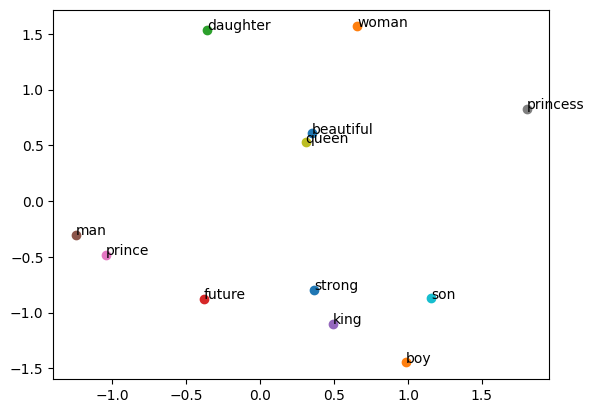

In [ ]:
import matplotlib.pyplot as plt
for word,cordinate in word_embeddings.items():
    plt.scatter(cordinate[0],cordinate[1])
    plt.annotate(word, (cordinate[0],cordinate[1]))



In [ ]:
for bi in bigrams:
  print(bi)

('future', 'king')
['king', 'future']
('future', 'prince')
['prince', 'future']
('king', 'prince')
['prince', 'king']
('daughter', 'princess')
['princess', 'daughter']
('son', 'prince')
['prince', 'son']
('man', 'king')
['king', 'man']
('woman', 'queen')
['queen', 'woman']
('princess', 'queen')
['queen', 'princess']
('prince', 'strong')
['strong', 'prince']
('prince', 'man')
['man', 'prince']
('strong', 'man')
['man', 'strong']
('princess', 'beautiful')
['beautiful', 'princess']
('princess', 'woman')
['woman', 'princess']
('beautiful', 'woman')
['woman', 'beautiful']
('prince', 'boy')
['boy', 'prince']
('prince', 'king')
['king', 'prince']
('boy', 'man')
['man', 'boy']
